# IR Curve Jacobian & Par Sensitivities

This notebook bootstraps an **ESTR OIS curve** from market quotes and computes the **DV01 of an EUR Interest Rate Swap** in two equivalent representations:

| Representation | Space | Method |
|----------------|-------|--------|
| Zero-rate DV01 | Zero-rate pillars | TensorFlow `GradientTape` (AD) |
| Par DV01 | OIS par rates | Bootstrapping Jacobian $J$ |

The key result is the **Jacobian change-of-basis**:

$$\mathbf{p} = -\,\mathrm{diag}(d)\cdot J^{-\top}\cdot\mathbf{s}$$

---

In [1]:
import tensorquant as tq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime

## 1. Setup

In [2]:
ref_date = datetime.date(2026, 2, 25)
tq.Settings.evaluation_date = ref_date
calendar = tq.TARGET()
spot_date = calendar.advance(ref_date, 2, tq.TimeUnit.Days, tq.DayCounterConvention.Actual360)
daycounter = tq.DayCounter(tq.DayCounterConvention.Actual360)


disc_factor = [1.0, 0.99994584, 0.99989168, 0.99951658, 0.9991406 , 0.9987649 ,
       0.99839065, 0.99673568, 0.99514101, 0.99339432, 0.99192323,
       0.99029715, 0.98863157, 0.98713775, 0.98554218, 0.9839551 ,
       0.98242782, 0.98089875, 0.97629874, 0.97153803, 0.96660517,
       0.96174842, 0.94138678, 0.91977351, 0.89721652, 0.87378833,
       0.84958351, 0.82498703, 0.80030163, 0.77553358, 0.75077035,
       0.72609428]
dates = [datetime.date(2026, 2, 25), datetime.date(2026, 2, 26), datetime.date(2026, 2, 27),
       datetime.date(2026, 3, 6), datetime.date(2026, 3, 13),
       datetime.date(2026, 3, 20), datetime.date(2026, 3, 27),
       datetime.date(2026, 4, 27), datetime.date(2026, 5, 27),
       datetime.date(2026, 6, 29), datetime.date(2026, 7, 27),
       datetime.date(2026, 8, 27), datetime.date(2026, 9, 28),
       datetime.date(2026, 10, 27), datetime.date(2026, 11, 27),
       datetime.date(2026, 12, 28), datetime.date(2027, 1, 27),
       datetime.date(2027, 2, 26), datetime.date(2027, 5, 27),
       datetime.date(2027, 8, 27), datetime.date(2027, 11, 29),
       datetime.date(2028, 2, 28), datetime.date(2029, 2, 27),
       datetime.date(2030, 2, 27), datetime.date(2031, 2, 27),
       datetime.date(2032, 2, 27), datetime.date(2033, 2, 28),
       datetime.date(2034, 2, 27), datetime.date(2035, 2, 27),
       datetime.date(2036, 2, 27), datetime.date(2037, 2, 27),
       datetime.date(2038, 2, 26)]

disc_factor_6m = [1.0, 0.99825187, 0.99637211, 0.99459776, 0.99271565, 0.99103902,
       0.98924461, 0.98738827, 0.9856945 , 0.98390642, 0.98210685,
       0.98045037, 0.97874674, 0.97689044, 0.97528109, 0.97354905,
       0.97171404, 0.97005217, 0.96832325, 0.95736063, 0.93499112,
       0.91160022, 0.88753418, 0.86291687, 0.83774287, 0.81241287,
       0.78703628, 0.76174335, 0.7366608 , 0.71196302, 0.68764535,
       0.66414527]
dates_6m = [datetime.date(2026, 2, 25), datetime.date(2026, 3, 27), datetime.date(2026, 4, 27),
       datetime.date(2026, 5, 27), datetime.date(2026, 6, 29),
       datetime.date(2026, 7, 27), datetime.date(2026, 8, 27),
       datetime.date(2026, 9, 28), datetime.date(2026, 10, 27),
       datetime.date(2026, 11, 27), datetime.date(2026, 12, 29),
       datetime.date(2027, 1, 27), datetime.date(2027, 2, 26),
       datetime.date(2027, 3, 30), datetime.date(2027, 4, 27),
       datetime.date(2027, 5, 27), datetime.date(2027, 6, 28),
       datetime.date(2027, 7, 27), datetime.date(2027, 8, 26),
       datetime.date(2028, 2, 28), datetime.date(2029, 2, 27),
       datetime.date(2030, 2, 27), datetime.date(2031, 2, 27),
       datetime.date(2032, 2, 27), datetime.date(2033, 2, 28),
       datetime.date(2034, 2, 27), datetime.date(2035, 2, 27),
       datetime.date(2036, 2, 27), datetime.date(2037, 2, 27),
       datetime.date(2038, 2, 26), datetime.date(2039, 2, 28),
       datetime.date(2040, 2, 27)]


estr_curve = tq.RateCurve.from_zcb(ref_date, dates, disc_factor, "LINEAR", tq.DayCounterConvention.Actual360)
eur6m_curve = tq.RateCurve.from_zcb(ref_date, dates_6m, disc_factor_6m, "LINEAR", tq.DayCounterConvention.Actual360)

market = {
    "IR:EUR:ESTR:SPOT":    estr_curve,   
    "IR:EUR:6M:SPOT":    eur6m_curve
}
market_env = tq.MarketEnvironment(market)

## 2. Curve Bootstrapping

Bootstrap an **ESTR OIS curve** from a set of market quotes (deposit rates and OIS par rates). The bootstrapper solves, for each instrument $i$:

$$\text{NPV}_i\bigl(r_0, r_1, \ldots, r_N\bigr) = 0$$

building the zero-rate vector $\{r_j\}$ pillar by pillar. Two types of instruments are used:

| Code | Instrument |
|------|------------|
| `Dp` | Cash deposit |
| `Os` | OIS swap |

In [3]:
curve_stripper_eur = tq.CurveBootstrap(evaluation_date=ref_date,
                                   daycount_convention=tq.DayCounterConvention.Actual365,
                                   market_env=market_env)

generators = ['Dp', 'Dp', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os',
       'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os',
       'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os', 'Os']
maturities = ['O/N', 'T/N', '1W', '2W', '3W', '1M', '2M', '3M', '4M', '5M', '6M',
       '7M', '8M', '9M', '10M', '11M', '1Y', '15M', '18M', '21M', '2Y',
       '3Y', '4Y', '5Y', '6Y', '7Y', '8Y', '9Y', '10Y', '11Y', '12Y']
quotes = np.array([1.95 , 1.95 , 1.93 , 1.933, 1.934, 1.933, 1.932, 1.931, 1.93 ,
       1.928, 1.927, 1.925, 1.922, 1.92 , 1.918, 1.916, 1.915, 1.909,
       1.912, 1.921, 1.934, 1.999, 2.076, 2.153, 2.23 , 2.305, 2.378,
       2.444, 2.506, 2.564, 2.62 ])/100

In [4]:
bootstrapped_curve = curve_stripper_eur.strip(generators, maturities, quotes, 'IR:EUR:ESTR:SPOT', tq.Currency.EUR)

0
1
2
3
4


## 3. Curve Inspection

Visualise the bootstrapped curve in three representations:

1. **Discount factors** $P(0,t)$ – the market-implied present value of 1€ at time $t$
2. **Zero rates** $r(t)$ – the continuously-compounded rate implied by $P(0,t)$
3. **Forward rates** $f(t, t+6M)$ – the 6-month rate starting at $t$, sensitive to the smoothness of the bootstrapped curve

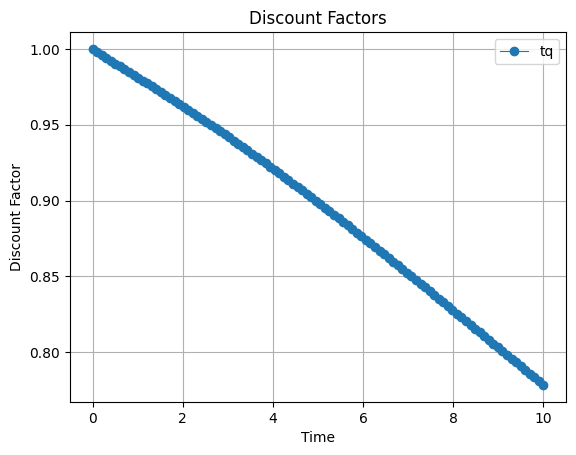

In [5]:
taus = np.linspace(0.0001,10, 100).tolist()
discount_tq = [bootstrapped_curve.discount(t) for t in taus]

plt.plot(taus, discount_tq, label='tq', marker='o',  linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Discount Factor')
plt.title('Discount Factors')
plt.legend()
plt.grid()
plt.show()

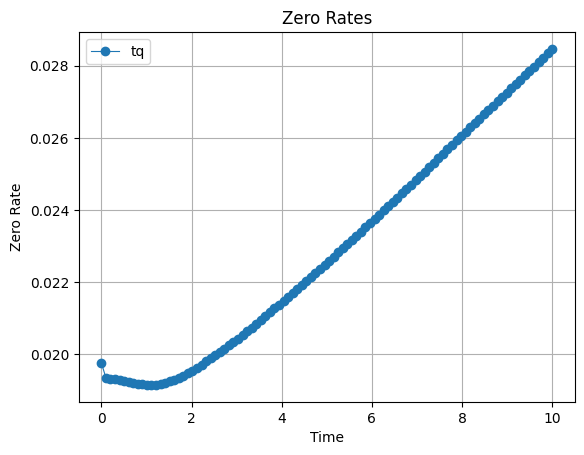

In [6]:
zerorate_tq = [bootstrapped_curve.zero_rate(t) for t in taus]

plt.plot(taus, zerorate_tq, label='tq', marker='o',  linewidth=0.8)
plt.xlabel('Time')
plt.ylabel('Zero Rate')
plt.title('Zero Rates')
plt.legend()
plt.grid()
plt.show()

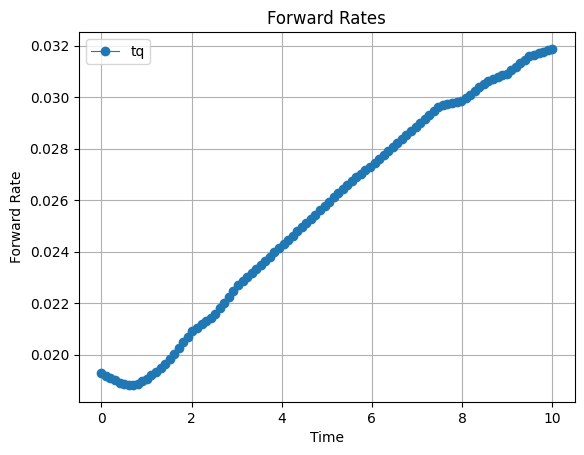

In [7]:
fwdrate_tq = [bootstrapped_curve.forward_rate(t, t+0.5) for t in taus]

plt.plot(taus, fwdrate_tq, label='tq', marker='o',  linewidth=0.8)

plt.xlabel('Time')
plt.ylabel('Forward Rate')
plt.title('Forward Rates')
plt.legend()
plt.grid()
plt.show()

## 4. Zero Rate DV01

Build a **pay-fixed EUR 10Y IRS** and compute its **DV01 in zero-rate space** using TensorFlow automatic differentiation. This is the foundation for the par-sensitivity transformation in section 5.

### 4.1 Instrument – EUR IRS

| Attribute | Value |
|-----------|-------|
| Currency | EUR |
| Notional | 1 M |
| Tenor | 10Y |
| Fixed leg | Annual, Actual/360, rate = 1% |
| Floating leg | 6M Euribor, semi-annual, Actual/360 |
| Settlement delay | T+3 |

In [8]:
currency = tq.Currency.EUR
mod_fol_convention = tq.BusinessDayConvention.ModifiedFollowing
daycount_fix = tq.DayCounterConvention.Actual360
daycount_flt = tq.DayCounterConvention.Actual360

settlement_delay = 3 
period_fixed_leg = "1Y"
period_float_leg = "6M"

eur6m_index = tq.IborIndex(calendar, 6, tq.TimeUnit.Months, tq.Currency.EUR, 2)

irs_eur6m_generator = tq.SwapGenerator(currency, settlement_delay,
                                        period_fixed_leg, period_float_leg,
                                        mod_fol_convention, 1e6,
                                        daycount_fix, daycount_flt,
                                        calendar, eur6m_index)
swap = irs_eur6m_generator.build(trade_date=ref_date, quote=0.01, term="10Y")

### 4.2 Pricing & Zero-Rate DV01

Price the swap and record the `GradientTape` to compute:

$$s_j = \frac{\partial \text{NPV}_{\text{swap}}}{\partial r_j}$$

where $r_j$ are the continuously-compounded zero rates at each ESTR pillar. The bar chart below shows the resulting DV01 profile (divided by $10^4$ to express in bps).

In [9]:
swap_engine = tq.SwapPricer()
swap_engine.price(swap, market_env, True)
sensitivities = swap_engine.tape.gradient(swap.price, [swap_engine.disc_curve._rates, swap_engine.fwd_curve._rates])

print(f"NPV FixedLeg: {swap.fixed_leg.price :,.0f}")
print(f"NPV FloatingLeg: {swap.floating_leg.price :,.0f}")
########
print(f"NPV Swap: {swap.price :,.0f}")

NPV FixedLeg: -89,516
NPV FloatingLeg: 241,064
NPV Swap: 151,548


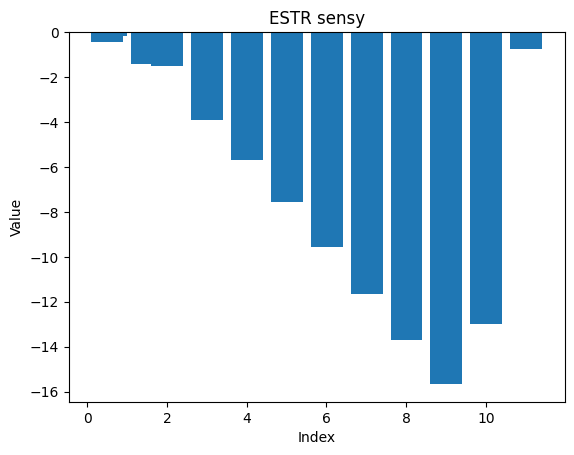

In [10]:
sensy_estr = pd.DataFrame([swap_engine.disc_curve._pillars, sensitivities[0]]).T
sensy_estr.columns = ['time', 'sensy_estr']
# sensy_estr.fillna(0., inplace = True)
sensy_estr.set_index('time', inplace = True)
sensy_estr['sensy_estr'] = sensy_estr['sensy_estr'].apply(tq.extract_value)
sensy_estr = sensy_estr/1e4

plt.bar(sensy_estr.index, sensy_estr['sensy_estr'])
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('ESTR sensy')
plt.show()

## 5. Par Sensitivity via Jacobian

## Step 1 — Zero rate sensitivity `s`

The `GradientTape` in the pricing cell computes, via automatic differentiation:

$$s_j = \frac{\partial \text{NPV}_\text{swap}}{\partial r_j} \qquad \text{(one value per ESTR curve pillar)}$$

This is a **partial derivative with the curve held fixed**: "if I shift only the zero rate at pillar $j$ by 1bp, how much does the swap NPV change?"  
The left chart shows that the values are concentrated around the 7Y–10Y pillars — as expected for a 10Y swap.

---

## Step 2 — What the bootstrapping Jacobian `J` contains

During `strip()`, the `ObjectiveFunction` fills the Jacobian row by row via `GradientTape`:

$$J[i, j] = \frac{\partial \text{NPV}_i}{\partial r_j} \qquad \text{(row = calibration instrument, column = zero rate)}$$

The matrix is **lower-triangular**: the 3Y OIS sees only rates up to year 3, not beyond.

---

## Step 3 — Deriving `dr / dq_k`

When the par rate $q_k$ moves by 1bp, Newton must re-calibrate to bring all NPVs back to zero.  
Differentiating the calibration condition $\text{NPV}_i\!\left(r(q)\right) = 0$ with respect to $q_k$ (only instrument $k$ depends on its own quote):

$$J \cdot \frac{\partial r}{\partial q_k} = -\underbrace{\frac{\partial \text{NPV}_k}{\partial q_k}}_{d_k} \cdot e_k \implies \frac{\partial r}{\partial q_k} = -d_k \cdot J^{-1} \cdot e_k$$

The par sensitivity of the swap is then:

$$p_k = s^\top \cdot \frac{\partial r}{\partial q_k} = -d_k \cdot \left(J^{-\top} \cdot s\right)_k$$

$$\boxed{p_k = -d_k \cdot \left(J^{-\top} \cdot s\right)_k}$$

---

## Step 4 — Why the normalization `d_k` is essential

$d_k = \partial \text{NPV}_k / \partial q_k$ is the **annuity of the $k$-th calibration instrument** (notional = 1).  
It scales strongly with maturity:

| Instrument | $\lvert d_k \rvert \approx$ | Meaning |
|---|---|---|
| O/N deposit | 0.003 | 1bp quote move → NPV changes by 0.003 € |
| 1Y OIS | ~1 | 1bp quote move → NPV changes by ~1 € |
| 10Y OIS | ~9 | 1bp quote move → NPV changes by ~9 € |

**Without this factor**, the Jacobian inverse is upper-triangular, so short-end pillars accumulate the full zero-rate sensitivity of the swap (concentrated at 9–10Y) without being scaled down by their small annuity → spuriously large values at the short end.

---

## Step 5 — How `calib_quote_dv01` ($d_k$) is computed

Inside `strip()`, after calibration, each instrument $k$ is re-priced with its quote bumped by 1bp (rates held fixed):

$$d_k = \frac{\text{NPV}_k(r^*, q_k + \varepsilon) - \text{NPV}_k(r^*, q_k)}{\varepsilon}, \quad \varepsilon = 10^{-4}$$

This finite-difference gives $\partial \text{NPV}_k / \partial q_k$ without any analytical assumption about instrument structure.

---

## Summary — Full formula

$$\mathbf{p} = -\,\mathrm{diag}(d) \cdot \left(J^{-\top} \cdot s\right)$$

Equivalently, using the pre-transposed Jacobian as in the code ($\tilde{J} = J^\top$):

$$\mathbf{p} = -\,\mathrm{diag}(d) \cdot \left(\tilde{J}^{-1} \cdot s\right)$$

The result (right chart) shows the par sensitivity concentrated around the **7Y–10Y par rates** — physically correct for a 10Y swap. Short-end buckets are essentially zero.


### 5.1 Jacobian Computation

Apply the formula $\mathbf{p} = -\,\mathrm{diag}(d)\cdot(J^{-\top}\cdot s)$ using the Jacobian matrix stored in `bootstrapped_curve.jacobian` and the annuity vector from `bootstrapped_curve.calib_quote_dv01`.

In [11]:
# ── Zero rate sensitivity as numpy array (handling None and TF tensors) ──────
sensy_zero_estr = np.array([
    float(s.numpy()) if s is not None else 0.
    for s in sensitivities[0]
])/1e4

# ── Jacobian of the bootstrapped ESTR curve: J[i,j] = dNPV_i / dr_j ─────────
#    We transpose in advance so that J_inv = (J^T)^{-1} = (J^{-1})^T
J     = bootstrapped_curve.jacobian.T.values    # (J^T)[j,i] = dNPV_i/dr_j
J_inv = np.linalg.inv(J)                        # = (J^{-1})^T

# ── Normalization: dNPV_k/dq_k for each calibration instrument ──────────────
#    The full formula is: p_k = -(J^{-T} · s)_k · dNPV_k/dq_k
#    Without this term, short pillars look huge because their
#    annuity is small (~0.003 for O/N) compared with long pillars (~12 for 12Y).
d = bootstrapped_curve.calib_quote_dv01.values  # dNPV_k/dq_k  (< 0 for payer instruments)

# ── Correct par sensitivity ──────────────────────────────────────────────────
#    p_k = -(J^{-T} · s)_k · dNPV_k/dq_k  =  (J_inv · s)_k · (-d_k)
sensy_par_estr = (J_inv @ sensy_zero_estr) * (-d)

sensy_par_df = pd.DataFrame(
    sensy_par_estr,
    index=bootstrapped_curve.jacobian.index,
    columns=['sensy_par']
)

### 5.2 Sanity Check – DV01 Conservation

The transformation from zero-rate space to par space must be **DV01-neutral**: the total DV01 of the swap is the same regardless of whether it is expressed in zero-rate or par coordinates.

$$\sum_j s_j = \sum_k p_k$$

The two cells below verify this identity numerically.

In [12]:
sensy_par_df.values.flatten().sum()

np.float64(-83.99814927827828)

In [13]:
sensy_zero_estr.sum()

np.float64(-85.31593260599662)

### 5.3 Comparison: Zero Rate vs Par DV01

Side-by-side bar charts comparing the two sensitivity vectors:

* **Left** – zero-rate DV01 $s_j$: distributed across pillars due to the interpolation structure of the curve.
* **Right** – par DV01 $p_k$: concentrated at the **7Y–10Y** par rates, which is the physically correct result for a 10Y swap.

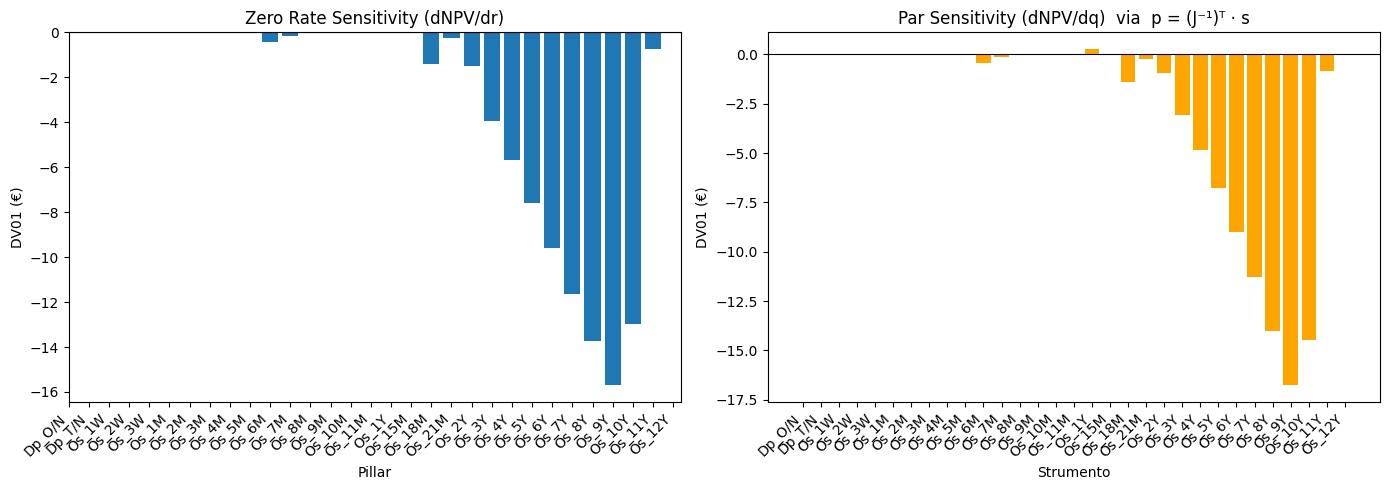

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Zero rate sensitivity ────────────────────────────────────────────────────
axes[0].bar(range(len(sensy_estr)), sensy_estr['sensy_estr'] )
axes[0].set_xticks(range(len(sensy_estr)))
axes[0].set_xticklabels(bootstrapped_curve.jacobian.index, rotation=45, ha='right')
axes[0].set_xlabel('Pillar')
axes[0].set_ylabel('DV01 (€)')
axes[0].set_title('Zero Rate Sensitivity (dNPV/dr)')
axes[0].axhline(0, color='black', linewidth=0.8)

# ── Par sensitivity ───────────────────────────────────────────────────────────
axes[1].bar(range(len(sensy_par_df)), sensy_par_df['sensy_par'], color='orange')
axes[1].set_xticks(range(len(sensy_par_df)))
axes[1].set_xticklabels(sensy_par_df.index, rotation=45, ha='right')
axes[1].set_xlabel('Strumento')
axes[1].set_ylabel('DV01 (€)')
axes[1].set_title('Par Sensitivity (dNPV/dq)  via  p = (J⁻¹)ᵀ · s')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()
